# 1. Project Overview

Analyze a synthetic 1,000-claim service-date snapshot. Preserve source facts, distinguish Claim Status from Outcome, and reconcile independent Python and SQL calculations. Amounts are in unspecified source currency units. Four Tableau dashboards are delivered separately; see the native validation report.

**Local:** run this notebook from `notebooks/` after installing `requirements.txt`.

**Colab:** upload and unzip the supplied project ZIP into `/content/`, run `%pip install -r /content/Healthcare-Claims-Denial-Analytics/requirements.txt`, then run all cells. The notebook locates that project directory automatically. This copy was executed in a Google Colab runtime.

# 2. Import Libraries

The functions used below live in the versioned `scripts/pipeline.py`. They contain the full preparation logic and can also run without a notebook.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
candidates=[Path.cwd(),Path.cwd().parent,Path('/content/Healthcare-Claims-Denial-Analytics')]
ROOT=next(p for p in candidates if (p/'scripts/pipeline.py').exists())
sys.path.insert(0,str(ROOT/'scripts'))
from pipeline import load_raw,audit,clean,engineer,quality_summary,eda,build_sql,validate,kpis,SOURCE
plt.rcParams.update({'font.family':'DejaVu Sans','figure.dpi':110,'axes.spines.top':False,'axes.spines.right':False})
print('Project:',ROOT.name)


Project: Healthcare-Claims-Denial-Analytics


# 3. Load Raw Data

All source columns load as strings first, preserving identifiers and leading zeros. The raw CSV is never overwritten. Date parsing uses explicit US month/day/year, confirmed by source values such as 06/21/2024.

In [2]:
raw=load_raw()
print('Shape:',raw.shape)
display(raw.head())
display(raw.dtypes.rename('loaded_type').to_frame())

Shape: (1000, 15)


,claim_id,provider_id,patient_id,date_of_service,billed_amount,procedure_code,diagnosis_code,allowed_amount,paid_amount,insurance_type,claim_status,reason_code,follow_up_required,ar_status,outcome
0,0HO1FSN4AP,0126528997,7936697103,08/07/2024,304,99231,A02.1,218,203,Self-Pay,Paid,Incorrect billing information,Yes,Pending,Partially Paid
1,9U86CI2P5A,6986719948,1547160031,06/21/2024,348,99213,A16.5,216,206,Medicare,Paid,Pre-existing condition,Yes,Open,Denied
2,1QEU1AIDAU,1355108115,2611585318,07/04/2024,235,99213,A00.1,148,119,Commercial,Under Review,Duplicate claim,No,Denied,Denied
3,WH7XDS8CEO,9991055906,7167948632,05/26/2024,112,99215,A18.6,79,69,Medicare,Denied,Authorization not obtained,No,Partially Paid,Denied
4,M6OJEZ8KGI,7382167012,2140226267,07/16/2024,406,99238,A17.9,320,259,Medicare,Denied,Authorization not obtained,No,On Hold,Denied


,loaded_type
claim_id,string
provider_id,string
patient_id,string
date_of_service,string
billed_amount,string
procedure_code,string
diagnosis_code,string
allowed_amount,string
paid_amount,string
insurance_type,string


# 4. Data Audit

This audit precedes transformations. Inspect shape, uniqueness, missing cells, duplicates, financial ranges and categorical values. The full reports are saved under `data/audit/`.

In [3]:
audit_table=audit(raw)
display(audit_table)
display(pd.read_csv(ROOT/'data/audit/column_profile.csv'))
display(pd.read_csv(ROOT/'data/audit/financial_ranges.csv'))
for col in ['insurance_type','claim_status','reason_code','follow_up_required','ar_status','outcome']:
    print(col, raw[col].value_counts().to_dict())

,check,result,action
0,Rows,1000,retain
1,Columns,15,retain
2,Exact duplicate rows,0,remove exact repeats only; preserve raw
3,Duplicate Claim IDs,0,stop on conflicting duplicates
4,Missing cells,0,required fields fail validation
5,Invalid dates,0,flag; stop required-date validation
6,billed_amount negative,0,retain + flag; invalid numbers stop validation
7,billed_amount zero,0,retain + flag; invalid numbers stop validation
8,billed_amount invalid,0,retain + flag; invalid numbers stop validation
9,allowed_amount negative,0,retain + flag; invalid numbers stop validation


,field,loaded_dtype,unique_count,missing_count
0,claim_id,string,1000,0
1,provider_id,string,1000,0
2,patient_id,string,1000,0
3,date_of_service,string,143,0
4,billed_amount,string,363,0
5,procedure_code,string,10,0
6,diagnosis_code,string,100,0
7,allowed_amount,string,332,0
8,paid_amount,string,311,0
9,insurance_type,string,4,0


,Unnamed: 0,billed_amount,allowed_amount,paid_amount
0,count,1000.00000,1000.000000,1000.000000
1,mean,297.19100,223.112000,200.754000
2,std,116.36365,90.784731,83.353688
3,min,100.00000,64.000000,53.000000
4,25%,197.00000,147.750000,133.000000
5,50%,297.00000,225.000000,200.000000
6,75%,395.00000,289.000000,262.000000
7,max,500.00000,442.000000,423.000000


insurance_type {'Commercial': 259, 'Medicaid': 259, 'Self-Pay': 249, 'Medicare': 233}
claim_status {'Under Review': 338, 'Paid': 334, 'Denied': 328}
reason_code {'Authorization not obtained': 154, 'Incorrect billing information': 142, 'Patient eligibility issues': 126, 'Missing documentation': 126, 'Pre-existing condition': 121, 'Duplicate claim': 113, 'Service not covered': 111, 'Lack of medical necessity': 107}
follow_up_required {'Yes': 522, 'No': 478}
ar_status {'Partially Paid': 184, 'On Hold': 177, 'Pending': 162, 'Open': 160, 'Closed': 160, 'Denied': 157}
outcome {'Paid': 357, 'Denied': 331, 'Partially Paid': 312}


# 5. Data Quality Checks

Rules were frozen after inspecting the actual source. A contradiction flag marks Denied with Paid/Partially Paid outcome, or Paid with Denied outcome. Under Review with a paid outcome is separately ambiguous. These are review rules, not clinical or adjudication conclusions. Open AR statuses are explicitly enumerated in the rulebook. Format checks describe source patterns only; they do not validate clinical codes.

In [4]:
display(pd.crosstab(raw.claim_status,raw.outcome))
display(pd.crosstab(raw.claim_status,raw.ar_status))
rules=json.loads((ROOT/'docs/rules.json').read_text())
display(pd.Series({k:v for k,v in rules.items() if k!='source_sha256'},name='frozen_vocabulary'))

outcome,Denied,Paid,Partially Paid
claim_status,,,
Denied,112,119,97
Paid,99,116,119
Under Review,120,122,96


ar_status,Closed,Denied,On Hold,Open,Partially Paid,Pending
claim_status,,,,,,
Denied,51,46,54,57,63,57
Paid,56,52,68,41,63,54
Under Review,53,59,55,62,58,51


insurance_type               [Commercial, Medicaid, Medicare, Self-Pay]
claim_status                               [Denied, Paid, Under Review]
reason_code           [Authorization not obtained, Duplicate claim, ...
follow_up_required                                            [No, Yes]
ar_status             [Closed, Denied, On Hold, Open, Partially Paid...
outcome                                  [Denied, Paid, Partially Paid]
Name: frozen_vocabulary, dtype: object

# 6. Data Cleaning

Trim whitespace, canonicalize known category capitalization, parse dates, convert amounts, and preserve IDs/codes as text. Required missing/invalid fields, unknown categories and conflicting claim IDs stop the build. Only identical records are deduplicated; none occur in this input.

In [5]:
cleaned=clean(raw)
print('Rows retained:',len(cleaned),'of',len(raw))
display(cleaned.dtypes.rename('clean_type').to_frame())

Rows retained: 1000 of 1000


,clean_type
claim_id,string
provider_id,string
patient_id,string
date_of_service,datetime64[us]
billed_amount,Int64
procedure_code,string
diagnosis_code,string
allowed_amount,Int64
paid_amount,Int64
insurance_type,string


# 7. Feature / Metric Engineering

Gross unpaid is billed minus paid, without assuming collectibility. Ratios return null at zero denominators. Portfolio rates use aggregate numerators and denominators. ISO weeks and Monday=1 weekday numbering are documented.

In [6]:
claims=engineer(cleaned)
display(quality_summary(claims))
display(pd.Series(kpis(claims),name='value').to_frame())
display(claims[['claim_id','gross_unpaid_amount','allowed_amount_gap','claim_status_denied_flag','outcome_denied_flag','status_consistency_flag']].head())

,check,result,action
0,Rows,1000,retain
1,Columns,15,retain
2,Exact duplicate rows,0,remove exact repeats only; preserve raw
3,Duplicate Claim IDs,0,stop on conflicting duplicates
4,Missing cells,0,required fields fail validation
5,Invalid dates,0,flag; stop required-date validation
6,billed_amount negative,0,retain + flag; invalid numbers stop validation
7,billed_amount zero,0,retain + flag; invalid numbers stop validation
8,billed_amount invalid,0,retain + flag; invalid numbers stop validation
9,allowed_amount negative,0,retain + flag; invalid numbers stop validation


,value
total_claims,1000.000000
total_billed_amount,297191.000000
total_allowed_amount,223112.000000
total_paid_amount,200754.000000
denied_claims,328.000000
outcome_denied_claims,331.000000
paid_claims,334.000000
under_review_claims,338.000000
follow_up_claims,522.000000
gross_unpaid_amount,96437.000000


,claim_id,gross_unpaid_amount,allowed_amount_gap,claim_status_denied_flag,outcome_denied_flag,status_consistency_flag
0,0HO1FSN4AP,101,15,0,0,0
1,9U86CI2P5A,142,10,0,1,1
2,1QEU1AIDAU,116,29,0,1,0
3,WH7XDS8CEO,43,10,1,1,0
4,M6OJEZ8KGI,147,61,1,1,0


# 8. Exploratory Data Analysis

The figures answer descriptive operational questions. September ends on day 20, and group differences are not evidence of causation. Provider/patient IDs occur once each, limiting longitudinal comparisons.

,insurance_type,claims,billed,paid,gross_unpaid,denied,follow_up,open_ar,denial_rate,follow_up_rate,payment_rate
0,Commercial,259,78520,53165,25355,89,140,176,0.343629,0.540541,0.677089
1,Medicaid,259,78094,53177,24917,75,142,177,0.289575,0.548263,0.680936
2,Medicare,233,66052,44156,21896,84,114,158,0.360515,0.489270,0.668504
3,Self-Pay,249,74525,50256,24269,80,126,172,0.321285,0.506024,0.674351


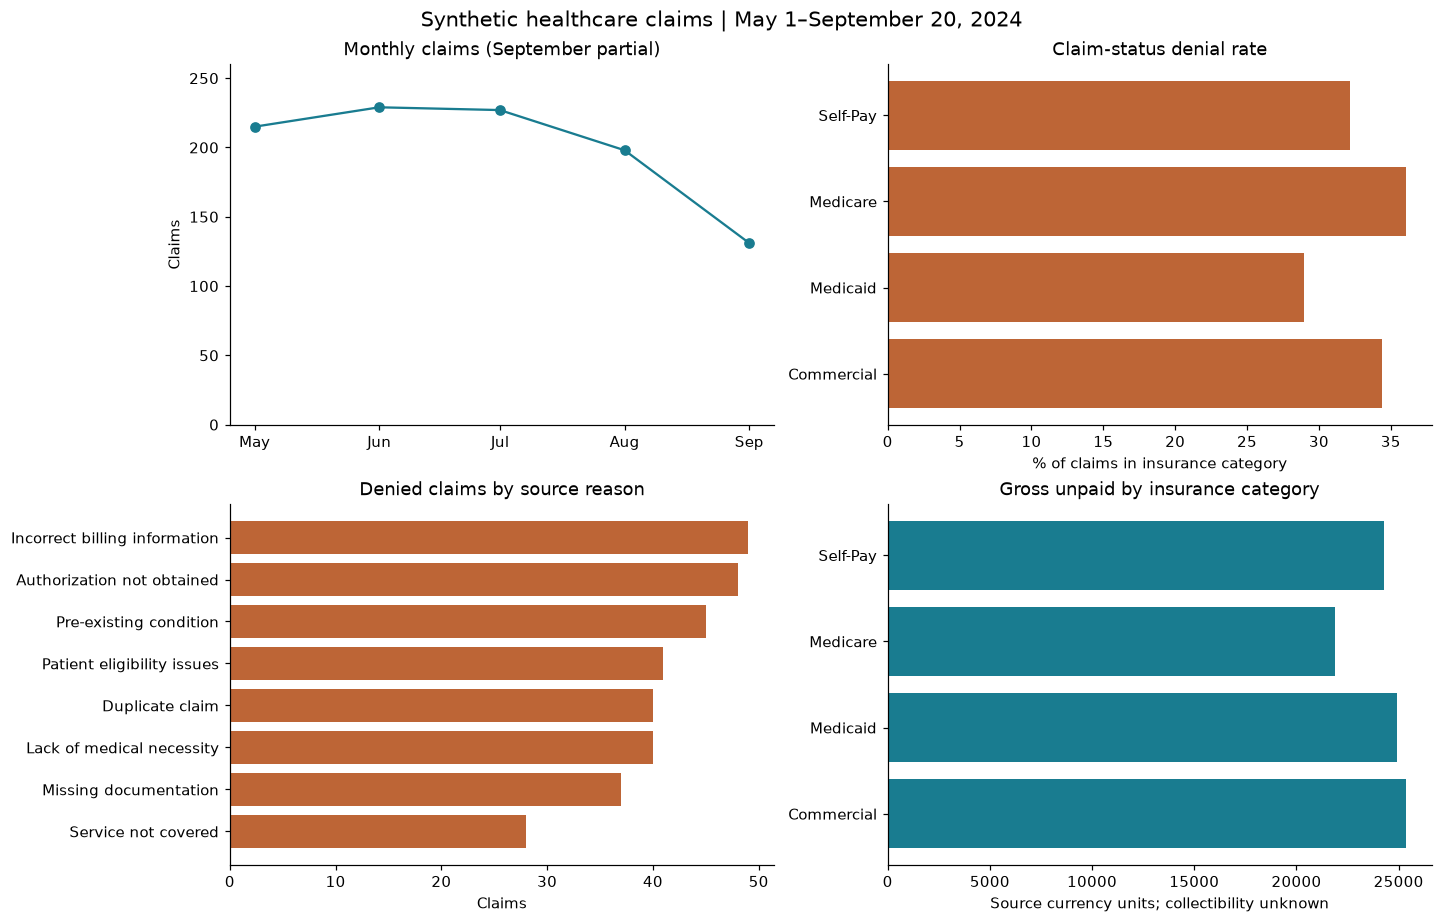

In [7]:
insurance=eda(claims)
display(insurance)
fig,axes=plt.subplots(2,2,figsize=(13,8),constrained_layout=True)
monthly=claims.groupby('service_month_start').agg(claims=('claim_id','nunique'),denials=('claim_status_denied_flag','sum'))
axes[0,0].plot(monthly.index,monthly.claims,marker='o',color='#197c90');axes[0,0].set_title('Monthly claims (September partial)');axes[0,0].set_ylabel('Claims')
axes[0,0].set_xticks(monthly.index,monthly.index.strftime('%b'));axes[0,0].set_ylim(0,260)
axes[0,1].barh(insurance.insurance_type,insurance.denial_rate*100,color='#bd6536');axes[0,1].set_title('Claim-status denial rate');axes[0,1].set_xlabel('% of claims in insurance category')
reasons=claims.loc[claims.claim_status.eq('Denied')].reason_code.value_counts().sort_values()
axes[1,0].barh(reasons.index,reasons.values,color='#bd6536');axes[1,0].set_title('Denied claims by source reason');axes[1,0].set_xlabel('Claims')
axes[1,1].barh(insurance.insurance_type,insurance.gross_unpaid,color='#197c90');axes[1,1].set_title('Gross unpaid by insurance category');axes[1,1].set_xlabel('Source currency units; collectibility unknown')
fig.suptitle('Synthetic healthcare claims | May 1–September 20, 2024',fontsize=14,y=1.03)
(ROOT/'docs/figures').mkdir(exist_ok=True)
fig.savefig(ROOT/'docs/figures/exploratory_analysis.png',dpi=150,bbox_inches='tight',pad_inches=0.25)
display(fig);plt.close(fig)

# 9. Export Clean Dataset

Exports retain all source columns plus derived metrics and quality flags. `claims_staging.csv` contains only the normalized source fields for PostgreSQL loading.

In [8]:
claims.to_csv(ROOT/'data/processed/claims_cleaned.csv',index=False,date_format='%Y-%m-%d')
claims[SOURCE].to_csv(ROOT/'data/processed/claims_staging.csv',index=False,date_format='%Y-%m-%d')
print('Exported',len(claims),'claims and',len(claims.columns),'analytical fields.')

Exported 1000 claims and 40 analytical fields.


# 10. Export Tableau Dataset

This is a backend data export only. The SQL runner creates dimensions and a claim-grain fact table, recomputes every metric in SQL, executes 37 analyses and exports the business view. It does not open or operate Tableau. The resulting CSV feeds the delivered Hyper-backed workbook.

In [9]:
connection,sql_export=build_sql(claims)
display(connection.execute('SELECT * FROM vw_kpi_summary').df().T)
print('Analytical view export rows:',len(sql_export))

,0
total_claims,1000.000000
total_billed_amount,297191.000000
total_allowed_amount,223112.000000
total_paid_amount,200754.000000
denied_claims,328.000000
outcome_denied_claims,331.000000
paid_claims,334.000000
under_review_claims,338.000000
follow_up_claims,522.000000
gross_unpaid_amount,96437.000000


Analytical view export rows: 1000


# 11. Validation Summary

Independent Python and SQL row-level checks cover all fields and key metrics. The separate PostgreSQL runner and boundary tests have additional reports. Native Tableau checks were performed separately in the app; their recorded observations are in tableau_native_validation.csv, not produced by this notebook.

In [10]:
validation=validate(claims,connection,sql_export)
display(validation)
connection.close()
print('Python / DuckDB:',validation.status.value_counts().to_dict())
pgpath=ROOT/'data/exports/postgres_validation.json'
if pgpath.exists():
    pg=json.loads(pgpath.read_text());print(pg['engine']);display(pd.DataFrame(pg['checks']))
tests=ROOT/'data/exports/backend_test_results.csv'
if tests.exists():display(pd.read_csv(tests))
print('Tableau: see separate native validation report. Google Colab runtime: executed; see colab_execution_report.json.')

,validation,expected,actual,status,scope
0,total_claims,1000,1000.0,PASS,Python vs executed SQL
1,total_billed_amount,297191,297191.0,PASS,Python vs executed SQL
2,total_allowed_amount,223112,223112.0,PASS,Python vs executed SQL
3,total_paid_amount,200754,200754.0,PASS,Python vs executed SQL
4,denied_claims,328,328.0,PASS,Python vs executed SQL
...,...,...,...,...,...
57,row_match_service_week,1000,1000,PASS,Independent Python / SQL field comparison
58,row_match_service_day_of_week,1000,1000,PASS,Independent Python / SQL field comparison
59,row_match_service_month_start,1000,1000,PASS,Independent Python / SQL field comparison
60,unique_fact_claim_id,1000,1000,PASS,Fact grain


Python / DuckDB: {'PASS': 62}
PostgreSQL 18.3 (PGlite 0.5.8) on wasm32-unknown-emscripten, compiled by emcc (Emscripten gcc/clang-like replacement + linker emulating GNU ld) 3.1.74 (1092ec30a3fb1d46b1782ff1b4db5094d3d06ae5), 32-bit


,metric,python,postgres,status
0,total_claims,1000.000000,1000.000000,PASS
1,total_billed_amount,297191.000000,297191.000000,PASS
2,total_allowed_amount,223112.000000,223112.000000,PASS
3,total_paid_amount,200754.000000,200754.000000,PASS
4,denied_claims,328.000000,328.000000,PASS
5,outcome_denied_claims,331.000000,331.000000,PASS
6,paid_claims,334.000000,334.000000,PASS
7,under_review_claims,338.000000,338.000000,PASS
8,follow_up_claims,522.000000,522.000000,PASS
9,gross_unpaid_amount,96437.000000,96437.000000,PASS


,check,status,detail
0,missing ID rejected,PASS,Required input / category gate
1,invalid calendar date rejected,PASS,Required input / category gate
2,invalid amount rejected,PASS,Required input / category gate
3,unapproved category rejected,PASS,Required input / category gate
4,Exact duplicate not double counted,PASS,Original raw file remains unchanged
...,...,...,...
82,Q33 cross-engine results,PASS,16 result rows; open_ar_exposure
83,Q34 cross-engine results,PASS,5 result rows; monthly_quality_issues
84,Q35 cross-engine results,PASS,4 result rows; denial_definition_overlap
85,Q36 cross-engine results,PASS,1 result rows; denied_paid_value


Tableau: see separate native validation report. Google Colab runtime: executed; see colab_execution_report.json.
